<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/EX01_Segmentacao_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX01 — Segmentação de Clientes com K-Means
**UC: Análise de Dados de Negócio** · Aula 1

---

Segmentação RFM com K-Means, método Elbow e Silhouette, visualização de clusters e exportação para Power BI.

**Dataset:** Online Retail II (UCI ML Repository)  
**URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

**Outputs gerados:** `clientes_segmentados.csv` · `elbow_silhouette.png` · `clusters_scatter.png` · `radar_clusters.png`


In [2]:
# @title ⚙️ Configurações e Instalação de Dependências (executar uma vez por sessão)

!pip install -q ucimlrepo

In [13]:
# --- 0. Instalação de dependências ---
# pip install pandas numpy scikit-learn matplotlib seaborn ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#0891B2', '#0D9488', '#6366F1', '#F59E0B', '#EF4444']

In [14]:
# Caso não seja configurado o Google Drive
# Os ficheiros ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

Directório de output: /content/


## 01 — Leitura e Análise Exploratória

In [15]:
# Dataset: Online Retail II (UCI ML Repository)
# https://archive.ics.uci.edu/ml/datasets/Online+Retail+II

df_raw = pd.read_excel(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx',
    sheet_name='Year 2010-2011'
)


In [16]:
# Análise Exploratória Simples

print("Shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.info())
print(df_raw.isnull().sum())

Shape: (541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

## 02 — Pre-processamento e criação dos atributos RFM

In [8]:
# Cópia da tabela
df = df_raw.copy()

# Remover cancelamentos (faturas começadas por 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remover linhas sem Customer ID ou com quantidade/preço negativos
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Calcular valor da linha
df['Revenue'] = df['Quantity'] * df['Price']

# Data de referência: dia seguinte ao último registo
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\nData de referência (snapshot): {snapshot_date.date()}")

# Agregar por cliente
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print("\nEstatísticas RFM:")
print(rfm.describe().round(2))


Data de referência (snapshot): 2011-12-10

Estatísticas RFM:
       Customer ID  Recency  Frequency   Monetary
count      4338.00  4338.00    4338.00    4338.00
mean      15300.41    92.54       4.27    2054.27
std        1721.81   100.01       7.70    8989.23
min       12346.00     1.00       1.00       3.75
25%       13813.25    18.00       1.00     307.41
50%       15299.50    51.00       2.00     674.48
75%       16778.75   142.00       5.00    1661.74
max       18287.00   374.00     209.00  280206.02


## 03 — Seleção do nr. de segmentos (Elbow + Silhouete)

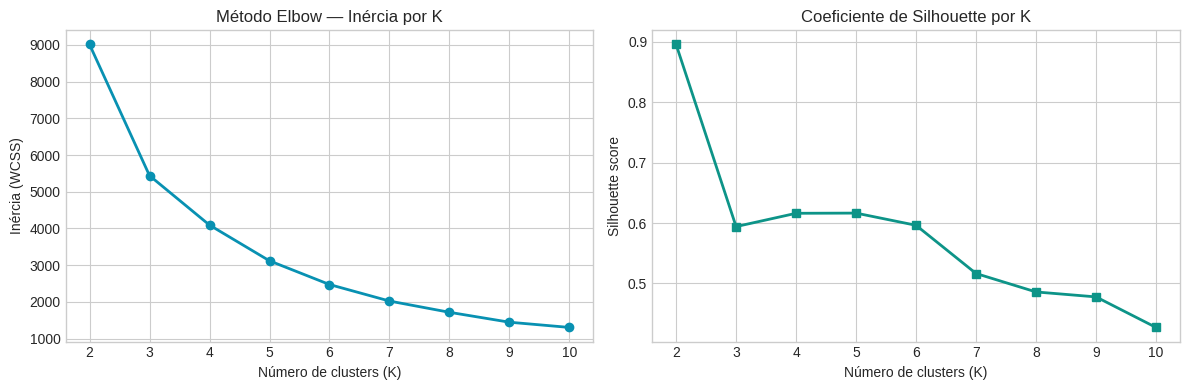

In [9]:
# Normalizar
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Testar K de 2 a 10
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

# Apresentar gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color=COLORS[0], linewidth=2)
axes[0].set_title('Método Elbow — Inércia por K')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')

axes[1].plot(list(K_range), sil_scores, marker='s', color=COLORS[1], linewidth=2)
axes[1].set_title('Coeficiente de Silhouette por K')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig('/content/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# *** TAREFA: Qual o K ideal? Justifica a tua escolha. ***

## 04 — Aplicar K-Means e caracterizar segmentos

In [10]:
K_IDEAL = 3   # ← Altera conforme a análise anterior

km_final = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Perfil médio de cada cluster
perfil = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print("\nPerfil médio dos clusters:")
print(perfil)

# Dimensão de cada cluster
print("\nDimensão:")
print(rfm['Cluster'].value_counts().sort_index())


Perfil médio dos clusters:
         Recency  Frequency  Monetary
Cluster                              
0          247.1        1.6     631.4
1           41.5        4.7    1855.9
2            6.0       66.4   85904.4

Dimensão:
Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64


## 05 — Visualização e intepretação

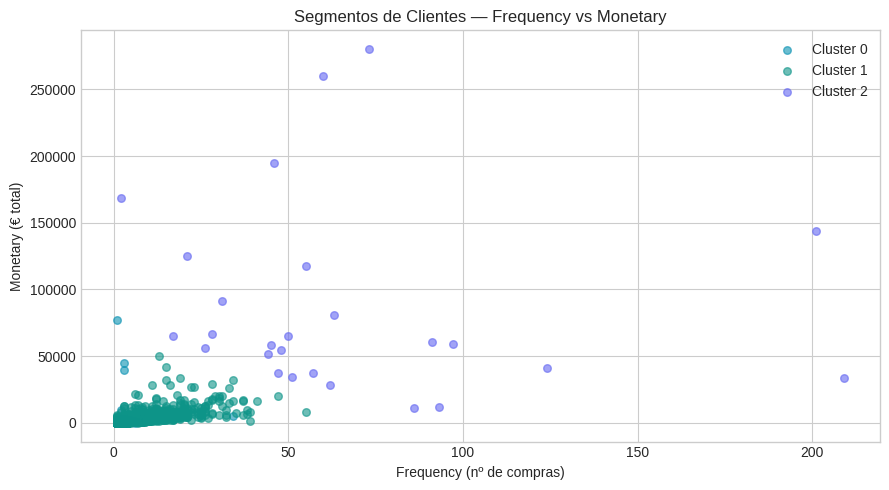

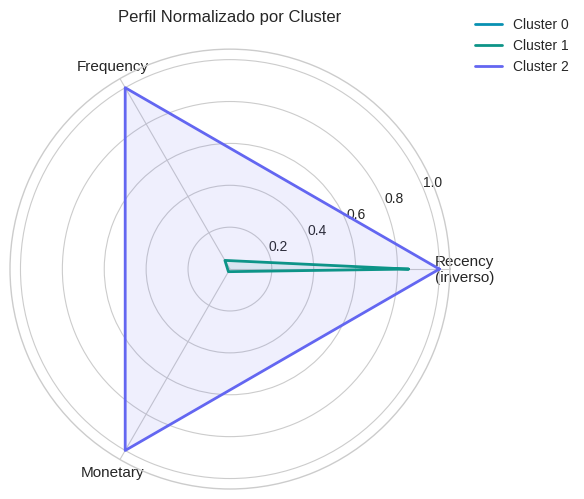

In [11]:
# Scatter plot: Frequency vs Monetary, colorido por cluster
fig, ax = plt.subplots(figsize=(9, 5))
for c in range(K_IDEAL):
    subset = rfm[rfm['Cluster'] == c]
    ax.scatter(subset['Frequency'], subset['Monetary'],
               label=f'Cluster {c}', alpha=0.6, s=30, color=COLORS[c % len(COLORS)])

ax.set_xlabel('Frequency (nº de compras)')
ax.set_ylabel('Monetary (€ total)')
ax.set_title('Segmentos de Clientes — Frequency vs Monetary')
ax.legend()
plt.tight_layout()
plt.savefig('/content/clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Spider/radar chart dos perfis normalizados
from matplotlib.patches import FancyArrowPatch
from math import pi

labels = ['Recency\n(inverso)', 'Frequency', 'Monetary']
num_vars = len(labels)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
rfm_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
rfm_norm['Recency'] = 1 - rfm_norm['Recency']  # inverter: menor recência = melhor

for idx, row in rfm_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, linewidth=2, label=f'Cluster {idx}', color=COLORS[idx % len(COLORS)])
    ax.fill(angles, vals, alpha=0.1, color=COLORS[idx % len(COLORS)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Perfil Normalizado por Cluster', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('/content/radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 06 — Exportar para POWER BI

In [12]:
rfm.to_csv('/content/clientes_segmentados.csv', index=False)
print("\nFicheiro 'clientes_segmentados.csv' guardado.")
print("Carrega este ficheiro no Power BI para construir o dashboard de segmentação.")


Ficheiro 'clientes_segmentados.csv' guardado.
Carrega este ficheiro no Power BI para construir o dashboard de segmentação.


# Perguntas de reflexão
1. Como nomeariam cada cluster com uma etiqueta de negócio? (ex: "Campeões", "Em Risco", "Hibernando", "Novos")
2. Que ação de marketing podem ser propostas para cada segmento?
3. Que variáveis adicionais poderiam enriquecer a segmentação?

